# FAST-UAV - Design of Experiments 

*Author: Félix Pollet - 2023* <br>

The `doe_fast` module offers the capability of running design of experiments on a FAST-UAV problem.

Various generators are available:
* The `List` generator reads cases from a user-defined array of DoE cases
* The `Uniform` generator creates random samples drawn from a uniform distribution
* The `Latin Hypercube` generator instanciates a [latin hypercube sampling](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
* The `Sobol` generator instanciates the [Sobol-Saltelli 2002 method provided by SALib](https://salib.readthedocs.io/en/latest/api.html#sobol-sensitivity-analysis). It is useful for performing a Sobol analysis, which is a form of [variance-based sensitivity analysis](https://en.wikipedia.org/wiki/Variance-based_sensitivity_analysis).
* The `Morris` generator instanciates the [method of Morris provided by SALib](https://salib.readthedocs.io/en/latest/api.html#method-of-morris). The [method of Morris](https://en.wikipedia.org/wiki/Morris_method) is a one-step-at-a-time method (OAT) for sensitivity analysis.

The examples below show some applications of the module.

In [13]:
# Import required librairies
import os.path as pth
import fastoad.api as oad
from fastuav.utils.postprocessing.sensitivity_analysis.sensitivity_analysis import doe_fast
import numpy as np
import plotly.graph_objects as go
import plotly

# Declare paths to folders and files
DATA_FOLDER_PATH = "./data"
WORK_FOLDER_PATH = "./workdir"
CONFIGURATION_FOLDER_PATH = pth.join(DATA_FOLDER_PATH, "configurations")
SOURCE_FOLDER_PATH = pth.join(DATA_FOLDER_PATH, "source_files")

## Example 1: running a model for many different input values

In [2]:
CONFIGURATION_FILE = pth.join(CONFIGURATION_FOLDER_PATH, "doe_simple_model.yaml")
SOURCE_FILE = pth.join(SOURCE_FOLDER_PATH, "problem_inputs_doe.xml")
oad.generate_inputs(CONFIGURATION_FILE, SOURCE_FILE, overwrite=True)

'D:/KangDH/fast_UAV/FAST-UAV/src/fastuav/notebooks/workdir/problem_inputs.xml'

In [3]:
INPUT_FILE = pth.join(WORK_FOLDER_PATH, "problem_inputs.xml")
oad.variable_viewer(INPUT_FILE)

In [4]:
# Definition of the DoE

# Inputs to be varied
x_dict = {
    "data:propulsion:multirotor:motor:speed:constant": [60, 80.0],  # range of variation
    "mission:operational:main_route:cruise:speed": [10.0, 20.0]
         }
# x_dict = {
#     "mission:operational:main_route:payload:mass": [0.5, 4.0],  # range of variation
#     "mission:operational:main_route:cruise:speed": [10.0, 20.0]
#          }

# Output(s) to observe
y_list = [
    "mission:operational:main_route:energy",
]

In [23]:
# Run DoE
method = "fullfactorial"  # full factorial sampling
n_samples = 10  # Number of samples
df = doe_fast(method, x_dict, y_list, CONFIGURATION_FILE, n_samples)

D:\KangDH\fast_UAV\FAST-UAV\src\fastuav\models\propulsion\propeller\performance_analysis.py:41: RuntimeWarning:

The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.



Traceback (most recent call last):
  File "c:\Users\user\.conda\envs\FastUAV_edit\lib\site-packages\openmdao\core\system.py", line 2674, in _call_user_function
    yield
  File "c:\Users\user\.conda\envs\FastUAV_edit\lib\site-packages\openmdao\core\explicitcomponent.py", line 292, in _compute_wrapper
    self.compute(self._inputs, self._outputs)
  File "D:\KangDH\fast_UAV\FAST-UAV\src\fastuav\utils\postprocessing\sensitivity_analysis\sensitivity_analysis.py", line 165, in compute
    fail = not p.run_driver().success
AttributeError: 'bool' object has no attribute 'success'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\user\.conda\envs\FastUAV_edit\lib\site-packages\openmdao\drivers\doe_driver.py", line 221, in _run_case
    self._problem().model.run_solve_nonlinear()
  File "c:\Users\user\.conda\envs\FastUAV_edit\lib\site-packages\openmdao\core\system.py", line 4558, in run_solve_nonlinear
    self._solve_nonli

In [24]:
print("Example 1 df length:", len(df))
if "optim_failed" in df.columns:
    print("Example 1 failed:", df['optim_failed'].sum())


Example 1 df length: 100
Example 1 failed: 100.0


In [6]:
# Plot DoE with Plotly

# Set variables to plot
x_name = list(x_dict.keys())[0]
y_name = list(x_dict.keys())[1]
z_name = y_list[0]

# Reshape data into a grid
x_vals = sorted(df[x_name].unique())
y_vals = sorted(df[y_name].unique())
#y_vals = [val / 1000 for val in y_vals]
z_grid = df.pivot(index=y_name, columns=x_name, values=z_name).values

# Create the contour plot    
fig = go.Figure()
fig.add_trace(go.Contour(
    x=x_vals, y=y_vals, z=z_grid, 
    connectgaps=True,
    contours=dict(start=df[z_name].min(), end=df[z_name].max(), showlabels=True),
    colorscale='RdBu_r' # Blackbody,Bluered,Blues,Cividis,Earth,Electric,Greens,Greys,Hot,Jet,Picnic,Portland,Rainbow,RdBu,Reds,Viridis,YlGnBu,YlOrRd. (add '_r' for reversed)
))

# Display the plot
fig.show()

## Example 2: DoE on the optimization problem

Sometimes you may want to run a DoE on an optimization problem rather than a model. The `doe_fast` module automatically detects if an optimization problem is defined in the configuration file, and each point of the DoE will run an optimization.

In [50]:
CONFIGURATION_FILE = pth.join(CONFIGURATION_FOLDER_PATH, "doe_optimization_problem.yaml")
SOURCE_FILE = pth.join(SOURCE_FOLDER_PATH, "problem_inputs_doe_optim.xml")
oad.generate_inputs(CONFIGURATION_FILE, SOURCE_FILE, overwrite=True)

'D:/KangDH/fast_UAV/FAST-UAV/src/fastuav/notebooks/workdir/problem_inputs.xml'

In [8]:
INPUT_FILE = pth.join(WORK_FOLDER_PATH, "problem_inputs.xml")
oad.variable_viewer(INPUT_FILE)

In [51]:
from fastuav.utils.postprocessing.sensitivity_analysis.sensitivity_analysis import doe_fast
import numpy as np

x_dict = {
    "models:weight:propulsion:multirotor:battery:mass:reference": np.array([0.5, 1.0]),
    "mission:sizing:main_route:hover:duration": np.array([10, 40]),
}

df = doe_fast("fullfactorial", x_dict, ["data:weight:mtow"], CONFIGURATION_FILE, 10)
df

c:\Users\user\.conda\envs\FastUAV_edit\lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds



52 out of 100 optimizations failed.


,models:weight:propulsion:multirotor:battery:mass:reference,mission:sizing:main_route:hover:duration,data:weight:mtow,optim_failed
0,0.500000,10.000000,10.313719,0.0
1,0.555556,10.000000,10.616811,0.0
2,0.611111,10.000000,10.940318,0.0
3,0.666667,10.000000,11.286592,0.0
4,0.722222,10.000000,11.658393,0.0
5,0.777778,10.000000,12.058986,0.0
6,0.833333,10.000000,12.492274,0.0
7,0.888889,10.000000,12.550910,0.0
8,0.944444,10.000000,12.934080,0.0
9,1.000000,10.000000,13.347161,0.0


In [53]:
import importlib
import fastuav.utils.postprocessing.sensitivity_analysis.sensitivity_analysis as sa
importlib.reload(sa)
from fastuav.utils.postprocessing.sensitivity_analysis.sensitivity_analysis import doe_fast


In [54]:
# Plot DoE with Plotly

# Minor calculations on the dataframe for better plotting
df = df.drop(df[df.optim_failed == 1.0].index)
df["data:propulsion:multirotor:battery:energy:density"] = df["data:propulsion:multirotor:battery:energy"] / 3.6 / df["data:weight:propulsion:multirotor:battery:mass"]
df["data:propulsion:multirotor:battery:energy:density"] = df["data:propulsion:multirotor:battery:energy:density"].astype(int)

# Set variables to plot
x_name = "data:propulsion:multirotor:battery:energy:density"
y_name = "mission:sizing:main_route:hover:duration"
z_name = "data:weight:mtow"

# Reshape data into a grid
x_vals = sorted(df[x_name].unique())
y_vals = sorted(df[y_name].unique())
z_grid = df.pivot(index=y_name, columns=x_name, values=z_name).values

# Create the contour plot    
fig = go.Figure()
fig.add_trace(go.Contour(
    x=x_vals, y=y_vals, z=z_grid, 
    connectgaps=True,
    line_smoothing=0.0,
    contours=dict(start=4.0, end=12, size=0.5, showlabels=True),
    colorbar=dict(
        title=dict(text='Total UAV mass [kg]', side='right', font=dict(size=16)),
        ticks='outside'
    ),
    colorscale='RdBu_r'
))

# Update layout
fig.update_layout(title=None, width=600, height=400, paper_bgcolor='rgba(0,0,0,0)',  plot_bgcolor='rgba(0,0,0,0)', font=dict(size=14),
                 margin=dict(l=10, r=10, t=0, b=0))
fig.update_xaxes(title='Battery energy density [Wh/kg]', ticks='outside', dtick=15, range=[130,260])
fig.update_yaxes(title='Hover endurance (min)', ticks='outside', range=[10,41])

# Display the plot
fig.show()

KeyError: 'data:propulsion:multirotor:battery:energy'

## Example 3 : Sobol analysis
The following example provides a more advanced example of what can be done using the `doe_fast` module. Ipywidget is used to set up an interactive interface to run a Sobol' analysis.

*For more details on this feature, please refer to the notebook [4_Uncertainty_Analysis](4_Uncertainty_analysis.ipynb).*

In [55]:
from fastuav.utils.postprocessing.sensitivity_analysis.sensitivity_analysis import sobol_analysis

# Retrieve the UAV design
CONFIGURATION_FILE = pth.join(CONFIGURATION_FOLDER_PATH, "doe_sobol_analysis.yaml")
REFERENCE_DESIGN_FILE = pth.join(SOURCE_FOLDER_PATH, "problem_outputs_DJI_M600_mdo.xml")

In [63]:
# Display deterministic results
oad.variable_viewer(REFERENCE_DESIGN_FILE)

In [74]:
# Carry out a sensitivity analysis on the UAV model
sobol_analysis(CONFIGURATION_FILE, REFERENCE_DESIGN_FILE)

    'data': [{'error_y': {'array': [], 'type': 'data'},
         …

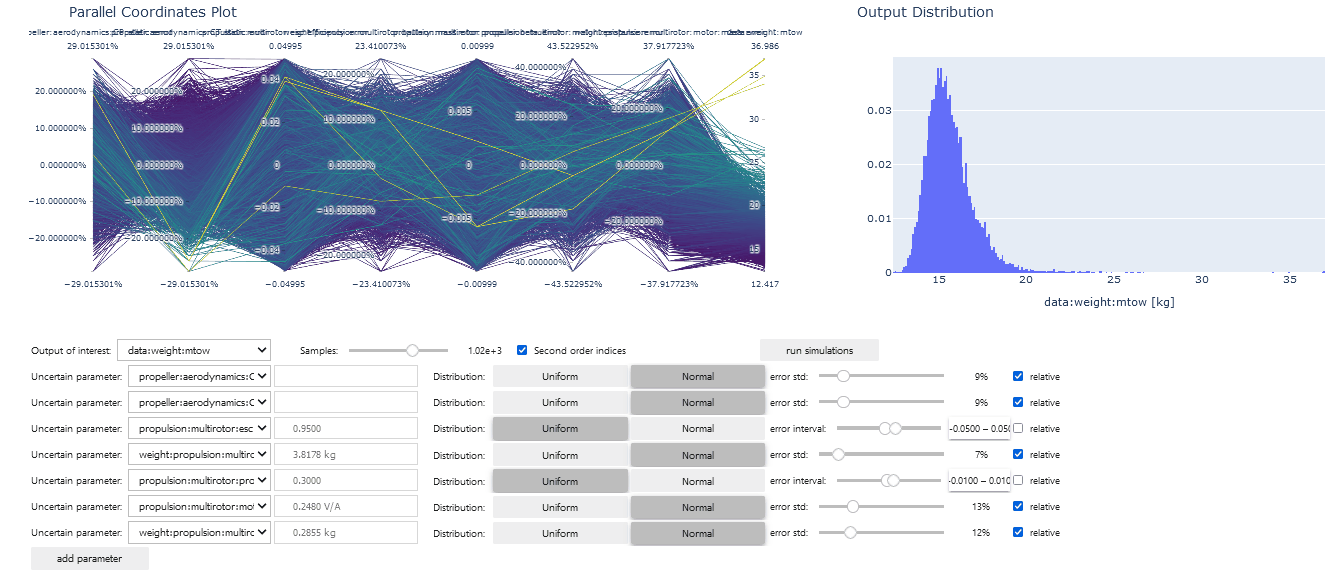![img](./img/uncertainty.gif)

In [73]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
import numpy as np
import fastoad.api as oad
from SALib.analyze import sobol
from fastuav.utils.postprocessing.sensitivity_analysis.sensitivity_analysis import doe_fast

# 1. OCR 기반 7개 불확실성 매개변수 설정 및 표시 이름 매핑
target_vars = {
    'uncertainty:propulsion:multirotor:propeller:Ct:static:polynomial:rel': 'Prop Ct',
    'uncertainty:propulsion:multirotor:propeller:Cp:static:polynomial:rel': 'Prop Cp',
    'uncertainty:propulsion:multirotor:esc:efficiency:rel': 'ESC Eff',
    'uncertainty:weight:propulsion:multirotor:propeller:mass:rel': 'Prop Mass',
    'uncertainty:propulsion:multirotor:propeller:diameter:rel': 'Prop Diameter',
    'uncertainty:propulsion:multirotor:motor:resistance:rel': 'Motor Res',
    'uncertainty:weight:propulsion:multirotor:motor:mass:rel': 'Motor Mass'
}

# 2. IPython Widgets(슬라이더 도구) 생성
sliders = {}
for var, name in target_vars.items():
    sliders[var] = widgets.FloatRangeSlider(
        value=[-0.1, 0.1],
        min=-0.5, max=0.5, step=0.01,
        description=name,
        readout_format='.0%',
        layout={'width': '500px'}
    )

run_button = widgets.Button(description="Run Simulation", button_style='primary')
output_area = widgets.Output()

def on_run_clicked(b):
    with output_area:
        clear_output(wait=True)
        print("시뮬레이션을 시작하고 있습니다. 약 1~2분 정도 소요됩니다...")
        
        # 슬라이더 값을 읽어와 x_dict 구성
        x_dict = {}
        for var, slider in sliders.items():
            x_dict[var] = [slider.value[0], slider.value[1], 'unif']
            
        y_list = ['data:performance:endurance:hover']
        n_samples = 32  # 필요 시 증가 (예: 64, 128)
        second_order = True
        
        # doe_fast 실행
        df = doe_fast("Sobol", x_dict, y_list, CONFIGURATION_FILE, ns=n_samples, calc_second_order=second_order)
        
        # SALib 평가용 데이터 구축
        problem_sobol = {
            'num_vars': len(x_dict),
            'names': list(x_dict.keys()),
            'bounds': list(x_dict.values())
        }
        Y_sobol = df[y_list[0]].to_numpy()
        
        # Sobol Analysis
        Si = sobol.analyze(problem_sobol, Y_sobol, calc_second_order=second_order)
        for s in Si:
            if isinstance(Si[s], np.ndarray):
                Si[s] = Si[s].clip(0)
                
        y_var = df[y_list[0]].var()
        labels = list(target_vars.values())
        
        # =====================================================================
        # 원래 GUI에서 사용되던 4가지 주요 그래프 (Bar, Heatmap, Histogram, Parallel Plot)
        # =====================================================================
        
        # Fig 1: 첫 번째 그래프 (1차 효과 및 전체 효과 소볼 지수)
        fig1 = go.Figure()
        fig1.add_trace(go.Bar(name="Total-effect", x=labels, y=np.sqrt(Si["ST"]*y_var), 
                              error_y=dict(type="data", array=np.sqrt(Si["ST_conf"]*y_var))))
        fig1.add_trace(go.Bar(name="First-order", x=labels, y=np.sqrt(Si["S1"]*y_var), 
                              error_y=dict(type="data", array=np.sqrt(Si["S1_conf"]*y_var))))
        fig1.update_layout(barmode="group", title="Contributions to the output standard deviation")
        
        # Fig 2: 두 번째 그래프 (변수 간 2차 상호작용 효과 히트맵)
        if second_order:
            fig2 = go.Figure(data=go.Heatmap(
                z=Si["S2"], x=labels, y=labels, hoverongaps=False,
                colorbar=dict(title="Sobol index", titleside="top")
            ))
            fig2.update_layout(title="First-order and Interaction effects")
            
        # Fig 4: 세 번째 그래프 (Output Distribution)
        fig4 = go.Figure(data=[go.Histogram(x=df[y_list[0]], histnorm='probability', autobinx=True)])
        fig4.update_layout(title="Output Distribution (Hover Endurance)")
        
        # Fig 5: 네 번째 그래프 (Parallel Coordinates Plot)
        dimensions = []
        for var in x_dict:
            dimensions.append(dict(label=target_vars[var], values=df[var], tickformat="%"))
        dimensions.append(dict(label="Hover Endurance", values=df[y_list[0]]))
        
        fig5 = go.Figure(data=go.Parcoords(labelangle=0, labelside="top", 
                                           line=dict(color=df[y_list[0]], colorscale="Viridis"), 
                                           dimensions=dimensions))
        fig5.update_layout(title="Parallel Coordinates Plot")
        
        # 모든 그래프 출력
        fig1.show()
        if second_order: fig2.show()
        fig4.show()
        fig5.show()

# 버튼 이벤트 연결 연동
run_button.on_click(on_run_clicked)

# 셀 실행 시 표시할 UI 레이아웃
ui = widgets.VBox([
    widgets.HTML("<h3>Sobol Analysis Interactive GUI</h2><p>마우스 드래그를 이용해 각 변수의 오차 범위를 조정한 뒤 Run 버튼을 클릭하세요.</p>"),
    *list(sliders.values()), 
    run_button, 
    output_area
])

display(ui)